In [1]:
import os
import re
import requests # HTTP 요청을 보내기 위한 라이브러리
import pandas as pd  
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone # 날짜·시간 처리를 위한 라이브러리
import xml.etree.ElementTree as ET # XML 데이터를 파싱하기 위한 표준 라이브러리

In [2]:
# 기상청 APIHub 인증키를 환경변수에서 불러오고, 없으면 기본값을 사용
KMA_AUTH_KEY = os.getenv("KMA_AUTH_KEY", "_IOlYUmbQ0SDpWFJm8NEtw")

In [3]:
# 분석 대상 지점(ASOS): 서울(108)
STN = 108

In [4]:
# 한국 표준시(KST, UTC+9) 기준의 현재 시각과 오늘 00:00 시각 설정
KST = timezone(timedelta(hours=9))

In [5]:
now_kst = datetime.now(KST)
today_kst = now_kst.replace(hour=0, minute=0, second=0, microsecond=0)

In [6]:
# datetime 객체를 API 요청에 필요한 문자열 형식(YYYYMMDDHHMM)으로 변환
tm1 = today_kst.strftime("%Y%m%d%H%M")
tm2 = now_kst.strftime("%Y%m%d%H%M")
print("조회 기간(KST):", tm1, "~", tm2)

조회 기간(KST): 202601090000 ~ 202601091433


In [7]:
# 기상청 APIHub의 ASOS 시간자료(kma_sfctm3) 조회를 위한 요청 URL 생성
# - tm1, tm2 : 조회 시작·종료 시각 (YYYYMMDDHHMM, KST 기준)
# - stn      : 관측 지점 번호 (예: 108 = 서울)
# - help=0   : 데이터만 조회 (help=1이면 필드 설명 포함)
# - authKey  : 기상청 APIHub 인증키

kma_url = (
    "https://apihub.kma.go.kr/api/typ01/url/kma_sfctm3.php"
    f"?tm1={tm1}&tm2={tm2}&stn={STN}&help=0&authKey={KMA_AUTH_KEY}"
)

In [8]:
# 기상청 API URL로 HTTP GET 요청을 보내고 (최대 대기 30초)
kma_resp = requests.get(kma_url, timeout=30)

In [9]:
# 응답 상태 코드가 200번대가 아니면 예외를 발생시켜 오류를 즉시 확인
kma_resp.raise_for_status()

In [10]:
# 응답으로 받은 본문 내용을 문자열(text) 형태로 저장
kma_text = kma_resp.text
kma_text

'#START7777\n#2345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234\n# YYMMDDHHMI STN  WD   WS GST  GST  GST     PA     PS PT    PR    TA    TD    HM    PV     RN     RN     RN     RN     SD     SD     SD WC WP WW                      CA  CA   CH CT        CT  CT  CT    VS   SS    SI ST    TS    TE    TE    TE    TE  ST   WH BF IR IX\n#        KST  ID  16  m/s  WD   WS   TM    hPa    hPa  -   hPa     C     C     %   hPa     mm    DAY    JUN    INT    HR3    DAY    TOT -- -- ---------------------- TOT MID  MIN -------- TOP MID LOW                  GD     C     5    10    20    30 SEA    m --  -  -\n202601090000 108   5  1.3  -9 -9.0   -9 1016.1 1027.2  8  -0.8  -5.6 -13.6  53.0   2.1   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        0   0   -9 -         -9  -9 

In [11]:
# typ01 응답은 설명 헤더와 실제 데이터가 섞여 있으므로, 먼저 빈 줄을 제거하고 각 줄의 앞뒤 공백을 정리
lines = [ln.strip() for ln in kma_text.splitlines() if ln.strip()]
lines

['#START7777',
 '#2345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234',
 '# YYMMDDHHMI STN  WD   WS GST  GST  GST     PA     PS PT    PR    TA    TD    HM    PV     RN     RN     RN     RN     SD     SD     SD WC WP WW                      CA  CA   CH CT        CT  CT  CT    VS   SS    SI ST    TS    TE    TE    TE    TE  ST   WH BF IR IX',
 '#        KST  ID  16  m/s  WD   WS   TM    hPa    hPa  -   hPa     C     C     %   hPa     mm    DAY    JUN    INT    HR3    DAY    TOT -- -- ---------------------- TOT MID  MIN -------- TOP MID LOW                  GD     C     5    10    20    30 SEA    m --  -  -',
 '202601090000 108   5  1.3  -9 -9.0   -9 1016.1 1027.2  8  -0.8  -5.6 -13.6  53.0   2.1   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        0   0   -9 -   

In [12]:
# 실제 데이터 행만 선별 / 형식: "YYYYMMDDHHMM STN ..." (12자리 시간 + 지점번호)
data_lines = [ln for ln in lines if re.match(r"^\d{12}\s+\d+", ln)]  # TM(12) + STN

# 데이터 행이 하나도 없으면 API 호출 실패로 판단
if not data_lines:
    # 디버깅을 위해 응답 일부 출력
    print("기상청 응답 일부:\n", kma_text[:500])
    # 인증키, 조회 기간, 지점번호 오류 가능성 안내
    raise RuntimeError("기상청 응답에서 데이터 라인을 찾지 못했습니다. authKey/기간/지점번호를 확인하세요.")

data_lines

['202601090000 108   5  1.3  -9 -9.0   -9 1016.1 1027.2  8  -0.8  -5.6 -13.6  53.0   2.1   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        0   0   -9 -         -9  -9  -9  3072 -9.0 -9.00 -9  -6.1  -1.8  -1.4   0.3   1.0  -9 -9.0 -9  3  2',
 '202601090100 108   2  1.8  -9 -9.0   -9 1016.2 1027.4 -9  -9.0  -6.1 -13.6  55.0   2.1   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        0   0   -9 -         -9  -9  -9  2982 -9.0 -9.00 -9  -6.3  -1.8  -1.5   0.2   1.0  -9 -9.0 -9  3 -9',
 '202601090200 108   5  2.5  -9 -9.0   -9 1015.9 1027.1 -9  -9.0  -6.3 -13.4  57.0   2.2   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        0   0   -9 -         -9  -9  -9  3147 -9.0 -9.00 -9  -6.3  -1.9  -1.6   0.2   1.1  -9 -9.0 -9  3 -9',
 '202601090300 108   5  2.3  -9 -9.0   -9 1015.8 1027.0  8  -0.2  -6.5 -13.8  56.0   2.1   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        0   0   -9 -      

In [15]:
# 데이터 행은 공백 개수가 일정하지 않으므로, 하나 이상의 공백(\s+)을 기준으로 각 행을 컬럼 단위로 분리
kma_rows = [re.split(r"\s+", ln) for ln in data_lines]
kma_rows

[['202601090000',
  '108',
  '5',
  '1.3',
  '-9',
  '-9.0',
  '-9',
  '1016.1',
  '1027.2',
  '8',
  '-0.8',
  '-5.6',
  '-13.6',
  '53.0',
  '2.1',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9',
  '-9',
  '-',
  '0',
  '0',
  '-9',
  '-',
  '-9',
  '-9',
  '-9',
  '3072',
  '-9.0',
  '-9.00',
  '-9',
  '-6.1',
  '-1.8',
  '-1.4',
  '0.3',
  '1.0',
  '-9',
  '-9.0',
  '-9',
  '3',
  '2'],
 ['202601090100',
  '108',
  '2',
  '1.8',
  '-9',
  '-9.0',
  '-9',
  '1016.2',
  '1027.4',
  '-9',
  '-9.0',
  '-6.1',
  '-13.6',
  '55.0',
  '2.1',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9.0',
  '-9',
  '-9',
  '-',
  '0',
  '0',
  '-9',
  '-',
  '-9',
  '-9',
  '-9',
  '2982',
  '-9.0',
  '-9.00',
  '-9',
  '-6.3',
  '-1.8',
  '-1.5',
  '0.2',
  '1.0',
  '-9',
  '-9.0',
  '-9',
  '3',
  '-9'],
 ['202601090200',
  '108',
  '5',
  '2.5',
  '-9',
  '-9.0',
  '-9',
  '1015.9',
  '1027.1',
  '-9',
  '-9.0',
  '-6.3',
  '-13.4',
  '57.0',
  '2.2',

In [16]:
# 경험적으로 자주 맞는 포지션: TM=0, STN=1, TA(기온)=10
TM_IDX, STN_IDX, TA_IDX = 0, 1, 11

In [17]:
# 분리된 기상청 데이터 행(kma_rows)에서
# 필요한 컬럼만 추출하여 pandas DataFrame 생성
kma_df = pd.DataFrame({
    # 관측 시각(TM): 문자열 형태의 YYYYMMDDHHMM
    "datetime": [r[TM_IDX] for r in kma_rows],
    
    # 관측 지점 번호(STN): 예) 108 = 서울
    "stn": [r[STN_IDX] for r in kma_rows],
    
    # 기온(TA): 컬럼 길이가 부족한 경우를 대비해 None 처리
    "temp_c": [r[TA_IDX] if len(r) > TA_IDX else None for r in kma_rows],
})

kma_df

,datetime,stn,temp_c
0,202601090000,108,-5.6
1,202601090100,108,-6.1
2,202601090200,108,-6.3
3,202601090300,108,-6.5
4,202601090400,108,-6.6
5,202601090500,108,-6.4
6,202601090600,108,-6.1
7,202601090700,108,-5.6
8,202601090800,108,-5.5
9,202601090900,108,-4.5


In [18]:
# 관측 시각 문자열(YYYYMMDDHHMM)을 datetime 타입으로 변환 / 형식이 맞지 않는 값은 NaT로 처리
kma_df["datetime"] = pd.to_datetime(
    kma_df["datetime"], format="%Y%m%d%H%M", errors="coerce"
)

kma_df

,datetime,stn,temp_c
0,2026-01-09 00:00:00,108,-5.6
1,2026-01-09 01:00:00,108,-6.1
2,2026-01-09 02:00:00,108,-6.3
3,2026-01-09 03:00:00,108,-6.5
4,2026-01-09 04:00:00,108,-6.6
5,2026-01-09 05:00:00,108,-6.4
6,2026-01-09 06:00:00,108,-6.1
7,2026-01-09 07:00:00,108,-5.6
8,2026-01-09 08:00:00,108,-5.5
9,2026-01-09 09:00:00,108,-4.5


In [19]:
# 기온 값을 숫자형(float)으로 변환 / 숫자로 변환 불가능한 값은 NaN으로 처리
kma_df["temp_c"] = pd.to_numeric(kma_df["temp_c"], errors="coerce")
kma_df

,datetime,stn,temp_c
0,2026-01-09 00:00:00,108,-5.6
1,2026-01-09 01:00:00,108,-6.1
2,2026-01-09 02:00:00,108,-6.3
3,2026-01-09 03:00:00,108,-6.5
4,2026-01-09 04:00:00,108,-6.6
5,2026-01-09 05:00:00,108,-6.4
6,2026-01-09 06:00:00,108,-6.1
7,2026-01-09 07:00:00,108,-5.6
8,2026-01-09 08:00:00,108,-5.5
9,2026-01-09 09:00:00,108,-4.5


In [20]:
# datetime이 없는 행 제거 후, 시간 순서대로 정렬하고 인덱스를 다시 정리
kma_df = (
    kma_df
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .reset_index(drop=True)
)

kma_df

,datetime,stn,temp_c
0,2026-01-09 00:00:00,108,-5.6
1,2026-01-09 01:00:00,108,-6.1
2,2026-01-09 02:00:00,108,-6.3
3,2026-01-09 03:00:00,108,-6.5
4,2026-01-09 04:00:00,108,-6.6
5,2026-01-09 05:00:00,108,-6.4
6,2026-01-09 06:00:00,108,-6.1
7,2026-01-09 07:00:00,108,-5.6
8,2026-01-09 08:00:00,108,-5.5
9,2026-01-09 09:00:00,108,-4.5


In [21]:
kma_df.head(3)

,datetime,stn,temp_c
0,2026-01-09 00:00:00,108,-5.6
1,2026-01-09 01:00:00,108,-6.1
2,2026-01-09 02:00:00,108,-6.3


In [22]:
# 전력거래소 OpenAPI(data.go.kr) 호출에 필요한 서비스키를 환경변수에서 불러오고, 없으면 기본값을 사용
KPX_SERVICE_KEY = os.getenv("KPX_SERVICE_KEY", "IfJN7A3cBBPttYf/FcFWC8pNDT3mi3SRSsDJmyAXQAUOlqvkQhP4ggZkHzhacIhEEJzcswWo8fraVeUBAOxQng==")

In [23]:
# 전력거래소 OpenAPI의 '오늘 전력수급 현황(5분 단위)' 조회 URL
kpx_url = "https://openapi.kpx.or.kr/openapi/sukub5mToday/getSukub5mToday"

In [24]:
# API 요청 시 전달할 파라미터 설정
kpx_params = {
    # data.go.kr에서 발급받은 서비스 인증키
    "serviceKey": KPX_SERVICE_KEY,
    
    # 조회 페이지 번호 (OpenAPI 표준 파라미터)
    "pageNo": 1,
    
    # 한 번에 조회할 데이터 개수 (충분히 크게 설정)
    "numOfRows": 1000,
}

In [25]:
# 전력거래소 OpenAPI로 HTTP GET 요청을 보내고 (파라미터 포함, 최대 대기 30초)
kpx_resp = requests.get(kpx_url, params=kpx_params, timeout=30)

In [26]:
# 응답 상태 코드가 정상(200번대)이 아닐 경우 예외 발생
kpx_resp.raise_for_status()

In [27]:
# 응답으로 받은 XML 본문을 문자열 형태로 저장
kpx_xml = kpx_resp.text
kpx_xml

'<?xml version="1.0" encoding="UTF-8" standalone="yes"?><response><header><resultCode>00</resultCode><resultMsg>OK</resultMsg><pageNo>1</pageNo><numOfRows>1000</numOfRows><totalCount>175</totalCount><pageSize>1</pageSize><startPage>1</startPage></header><body><items><item><baseDatetime>20260109000000</baseDatetime><suppAbility>99666.1</suppAbility><currPwrTot>71739.2</currPwrTot><forecastLoad>85100.0</forecastLoad><suppReservePwr>27926.9</suppReservePwr><suppReserveRate>38.9284</suppReserveRate><operReservePwr>12549.9</operReservePwr><operReserveRate>17.1677</operReserveRate></item><item><baseDatetime>20260109000500</baseDatetime><suppAbility>97164.9</suppAbility><currPwrTot>71949.4</currPwrTot><forecastLoad>85100.0</forecastLoad><suppReservePwr>25215.5</suppReservePwr><suppReserveRate>35.0461</suppReserveRate><operReservePwr>10851.8</operReservePwr><operReserveRate>14.8014</operReserveRate></item><item><baseDatetime>20260109001000</baseDatetime><suppAbility>97162.8</suppAbility><currP

In [28]:
# 문자열 형태의 XML 응답을 파싱하여 XML 트리 구조로 변환
root = ET.fromstring(kpx_xml)
root

<Element 'response' at 0x000002268859BF10>

In [29]:
# XML 구조 내에서 모든 item 태그를 검색(전력 수급 데이터는 item 단위로 반복 제공됨)
items = root.findall(".//item")

# item이 하나도 없으면 API 응답 오류로 판단
if not items:
    # 원인 파악을 위해 XML 응답 일부를 출력
    print("전력 응답(XML) 일부:\n", kpx_xml[:500])
    # 인증키 문제, 승인 상태, 호출 제한 등의 가능성 안내
    raise RuntimeError("전력거래소 응답에서 item을 찾지 못했습니다. serviceKey/승인 상태를 확인하세요.")

In [30]:
# 전력거래소 item 데이터들을 담을 리스트 초기화
kpx_rows = []

# 각 item(5분 단위 전력 수급 정보)에 대해 반복 처리
for it in items:
    
    # item 내부에서 특정 태그 값을 안전하게 가져오는 보조 함수
    def get(tag):
        el = it.find(tag)
        return el.text.strip() if el is not None and el.text is not None else None

    # 필요한 필드만 추출하여 딕셔너리 형태로 저장
    kpx_rows.append({
        # 기준 시각 (형식: YYYYMMDDHHMMSS)
        "datetime": get("baseDatetime"),
        
        # 현재 전력 수요량 (MW 단위)
        "curr_mw": get("currPwrTot"),
    })

kpx_rows

[{'datetime': '20260109000000', 'curr_mw': '71739.2'},
 {'datetime': '20260109000500', 'curr_mw': '71949.4'},
 {'datetime': '20260109001000', 'curr_mw': '71398.1'},
 {'datetime': '20260109001500', 'curr_mw': '70950.9'},
 {'datetime': '20260109002000', 'curr_mw': '70266.2'},
 {'datetime': '20260109002500', 'curr_mw': '70203.4'},
 {'datetime': '20260109003000', 'curr_mw': '69847.4'},
 {'datetime': '20260109003500', 'curr_mw': '69331.2'},
 {'datetime': '20260109004000', 'curr_mw': '69243.5'},
 {'datetime': '20260109004500', 'curr_mw': '69314.9'},
 {'datetime': '20260109005000', 'curr_mw': '69089.1'},
 {'datetime': '20260109005500', 'curr_mw': '68508.4'},
 {'datetime': '20260109010000', 'curr_mw': '68315.9'},
 {'datetime': '20260109010500', 'curr_mw': '68267.7'},
 {'datetime': '20260109011000', 'curr_mw': '68346.1'},
 {'datetime': '20260109011500', 'curr_mw': '67970.2'},
 {'datetime': '20260109012000', 'curr_mw': '67688.0'},
 {'datetime': '20260109012500', 'curr_mw': '67501.4'},
 {'datetim

In [31]:
# 전력거래소에서 수집한 리스트(kpx_rows)를 pandas DataFrame으로 변환
kpx_df = pd.DataFrame(kpx_rows)
kpx_df

,datetime,curr_mw
0,20260109000000,71739.2
1,20260109000500,71949.4
2,20260109001000,71398.1
3,20260109001500,70950.9
4,20260109002000,70266.2
...,...,...
170,20260109141500,78062.0
171,20260109142000,78228.9
172,20260109142500,78154.8
173,20260109143000,78467.6


In [32]:
# 기준 시각 문자열(YYYYMMDDHHMMSS)을 datetime 타입으로 변환 / 형식이 맞지 않는 값은 NaT로 처리
kpx_df["datetime"] = pd.to_datetime(
    kpx_df["datetime"], format="%Y%m%d%H%M%S", errors="coerce")
kpx_df

,datetime,curr_mw
0,2026-01-09 00:00:00,71739.2
1,2026-01-09 00:05:00,71949.4
2,2026-01-09 00:10:00,71398.1
3,2026-01-09 00:15:00,70950.9
4,2026-01-09 00:20:00,70266.2
...,...,...
170,2026-01-09 14:15:00,78062.0
171,2026-01-09 14:20:00,78228.9
172,2026-01-09 14:25:00,78154.8
173,2026-01-09 14:30:00,78467.6


In [33]:
# 현재 전력수요 값을 숫자형(float)으로 변환 / 숫자로 변환할 수 없는 값은 NaN 처리
kpx_df["curr_mw"] = pd.to_numeric(kpx_df["curr_mw"], errors="coerce")
kpx_df

,datetime,curr_mw
0,2026-01-09 00:00:00,71739.2
1,2026-01-09 00:05:00,71949.4
2,2026-01-09 00:10:00,71398.1
3,2026-01-09 00:15:00,70950.9
4,2026-01-09 00:20:00,70266.2
...,...,...
170,2026-01-09 14:15:00,78062.0
171,2026-01-09 14:20:00,78228.9
172,2026-01-09 14:25:00,78154.8
173,2026-01-09 14:30:00,78467.6


In [34]:
# datetime이 없는 행 제거 후, 시간 순으로 정렬하고 인덱스를 다시 정리
kpx_df = (
    kpx_df
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .reset_index(drop=True)
)
kpx_df

,datetime,curr_mw
0,2026-01-09 00:00:00,71739.2
1,2026-01-09 00:05:00,71949.4
2,2026-01-09 00:10:00,71398.1
3,2026-01-09 00:15:00,70950.9
4,2026-01-09 00:20:00,70266.2
...,...,...
170,2026-01-09 14:15:00,78062.0
171,2026-01-09 14:20:00,78228.9
172,2026-01-09 14:25:00,78154.8
173,2026-01-09 14:30:00,78467.6


In [35]:
kpx_df.head(3)

,datetime,curr_mw
0,2026-01-09 00:00:00,71739.2
1,2026-01-09 00:05:00,71949.4
2,2026-01-09 00:10:00,71398.1


In [36]:
# 기상 데이터의 관측 시각을 인덱스로 설정한 뒤, 시간 단위(1시간)로 리샘플링하여 기온의 시간 평균값을 계산
kma_hour = (
    kma_df
    .set_index("datetime")[["temp_c"]]  # datetime을 인덱스로 설정
    .resample("1H")                     # 1시간 단위로 재집계
    .mean()                             # 시간대별 평균 기온 계산
    .reset_index()                     # datetime을 다시 컬럼으로 복원
)
kma_hour

C:\Users\for\AppData\Local\Temp\ipykernel_12772\2486917416.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")                     # 1시간 단위로 재집계


,datetime,temp_c
0,2026-01-09 00:00:00,-5.6
1,2026-01-09 01:00:00,-6.1
2,2026-01-09 02:00:00,-6.3
3,2026-01-09 03:00:00,-6.5
4,2026-01-09 04:00:00,-6.6
5,2026-01-09 05:00:00,-6.4
6,2026-01-09 06:00:00,-6.1
7,2026-01-09 07:00:00,-5.6
8,2026-01-09 08:00:00,-5.5
9,2026-01-09 09:00:00,-4.5


In [37]:
# 전력 수요 데이터를 기준 시각을 인덱스로 설정한 뒤, # 5분 단위 데이터를 1시간 단위 평균 전력수요로 변환
kpx_hour = (
    kpx_df
    .set_index("datetime")[["curr_mw"]]   # datetime을 인덱스로 설정
    .resample("1H")                       # 1시간 단위로 재집계
    .mean()                               # 시간대별 평균 전력수요 계산
    .rename(columns={"curr_mw": "power_mw"})  # 컬럼명을 의미가 명확하도록 변경
    .reset_index()                        # datetime을 다시 컬럼으로 복원
)
kpx_hour

C:\Users\for\AppData\Local\Temp\ipykernel_12772\2282490883.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")                       # 1시간 단위로 재집계


,datetime,power_mw
0,2026-01-09 00:00:00,70153.475000
1,2026-01-09 01:00:00,67624.350000
2,2026-01-09 02:00:00,66052.875000
3,2026-01-09 03:00:00,65192.954545
4,2026-01-09 04:00:00,65316.533333
5,2026-01-09 05:00:00,66878.383333
6,2026-01-09 06:00:00,70778.658333
7,2026-01-09 07:00:00,77244.141667
8,2026-01-09 08:00:00,84389.508333
9,2026-01-09 09:00:00,84840.266667


In [38]:
# 기온 데이터와 전력 수요 데이터를 'datetime' 기준으로 병합
# - inner join을 사용하여 두 데이터에 모두 존재하는 시간대만 유지
merged = (
    pd.merge(kma_hour, kpx_hour, on="datetime", how="inner")
    
    # 기온 또는 전력수요 값이 없는 행 제거
    .dropna(subset=["temp_c", "power_mw"])
    
    # 시간 순서대로 정렬
    .sort_values("datetime")
    
    # 인덱스를 다시 정리
    .reset_index(drop=True)
)

# 병합 결과가 비어 있으면 데이터 수집 또는 시간 정합 실패로 판단
if merged.empty:
    raise RuntimeError("병합 결과가 비었습니다. 시간 범위/지점/수집 상태를 확인하세요.")

merged

,datetime,temp_c,power_mw
0,2026-01-09 00:00:00,-5.6,70153.475000
1,2026-01-09 01:00:00,-6.1,67624.350000
2,2026-01-09 02:00:00,-6.3,66052.875000
3,2026-01-09 03:00:00,-6.5,65192.954545
4,2026-01-09 04:00:00,-6.6,65316.533333
5,2026-01-09 05:00:00,-6.4,66878.383333
6,2026-01-09 06:00:00,-6.1,70778.658333
7,2026-01-09 07:00:00,-5.6,77244.141667
8,2026-01-09 08:00:00,-5.5,84389.508333
9,2026-01-09 09:00:00,-4.5,84840.266667


In [39]:
merged.head(5)

,datetime,temp_c,power_mw
0,2026-01-09 00:00:00,-5.6,70153.475000
1,2026-01-09 01:00:00,-6.1,67624.350000
2,2026-01-09 02:00:00,-6.3,66052.875000
3,2026-01-09 03:00:00,-6.5,65192.954545
4,2026-01-09 04:00:00,-6.6,65316.533333


In [40]:
# 기온(temp_c)과 전력수요(power_mw) 간의 피어슨 상관계수 계산
corr = merged["temp_c"].corr(merged["power_mw"])

# 계산된 상관계수를 소수점 셋째 자리까지 반올림하여 출력
print("기온-전력수요(시간평균) 피어슨 상관계수:", round(float(corr), 3))

기온-전력수요(시간평균) 피어슨 상관계수: 0.433


C:\Users\for\AppData\Local\Temp\ipykernel_12772\3003529582.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\for\AppData\Local\Temp\ipykernel_12772\3003529582.py:13: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


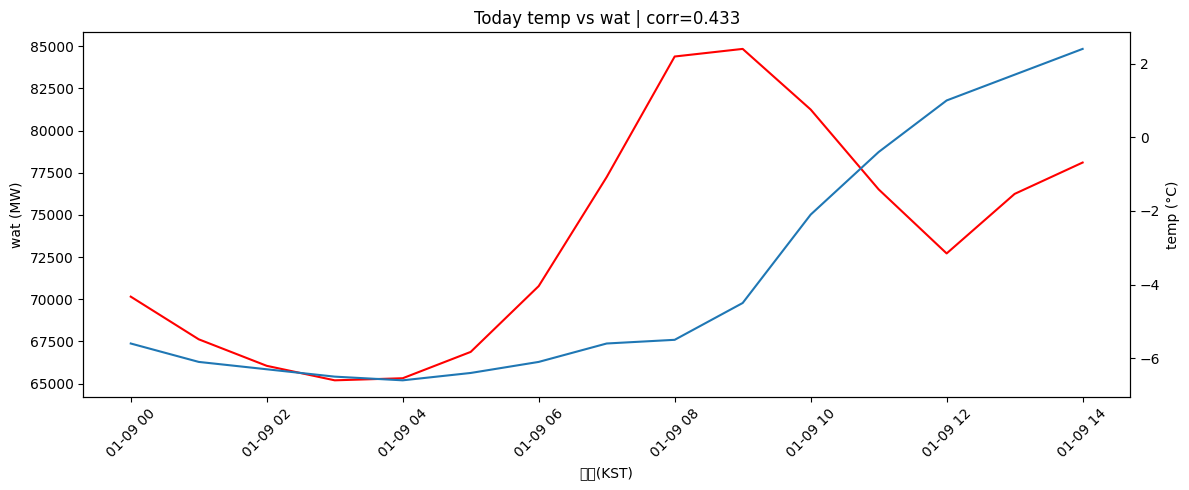

In [43]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(merged["datetime"], merged["power_mw"], color='red')
ax1.set_xlabel("시간(KST)")
ax1.set_ylabel("wat (MW)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(merged["datetime"], merged["temp_c"])
ax2.set_ylabel("temp (°C)")

plt.title(f"Today temp vs wat | corr={round(float(corr), 3)}")
plt.tight_layout()
plt.show()